# Orchestrator - Worker Workflow

The **Orchestrator-Worker** pattern is a multi-agent workflow where one central agent (**Orchestrator**) breaks a complex task into smaller subtasks and assigns them to specialized **Worker** agents. The workers perform their assigned tasks independently and return their results to the orchestrator, which combines them into the final output.

### Why do we need it?

* Handles complex tasks efficiently.
* Enables task decomposition.
* Allows specialization of agents.
* Improves scalability and maintainability.

### Architecture

```text
                User Request
                      │
                      ▼
             ┌────────────────┐
             │  Orchestrator  │
             └────────────────┘
                      │
        ┌─────────────┼─────────────┐
        ▼    worker   ▼  Node       ▼
   ┌────────┐    ┌────────┐    ┌────────┐
   │Worker 1│    │Worker 2│    │Worker 3│
   └────────┘    └────────┘    └────────┘
        │             │             │
        └─────────────┼─────────────┘
                      ▼
             ┌────────────────┐
             │ Collector or   |
             | Orchestrator   │
             └────────────────┘
                      │
                      ▼
                Final Output
```

### Workflow

```text
User Query
     ↓
Orchestrator
     ↓
Task Breakdown
     ↓
Worker Agents
     ↓
Worker Results
     ↓
Result Aggregation
     ↓
Final Response
```
### Key Idea

The Orchestrator does not perform all the work itself. It coordinates, delegates, and aggregates, while Worker agents execute the actual subtasks.

### Keep in Mind

* Orchestrator = Planner + Coordinator
* Worker = Specialized Task Executor
* Workers may run sequentially or in parallel.
* Final result is usually assembled by the Collector/Orchestrator.

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

### **Pydantic LLM Schema**

A **Pydantic LLM Schema** defines the exact structure of the output that the LLM must generate. It ensures that the response is returned in a predictable and validated format, making it easier to use the output in workflows, routing, and multi-agent systems.

**Key Idea:** Instead of free-form text, the LLM returns structured data that follows a predefined schema.


In [4]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

# Structured output schema used by the Orchestrator LLM.
# The LLM must return a list of tasks that can be assigned
# to Worker agents for execution.
class llm_schema(BaseModel):

    # List of subtasks generated by the Orchestrator.
    #
    # Example:
    # [
    #   "Write Introduction",
    #   "Write Main Content",
    #   "Write Conclusion"
    # ]
    tasks: List[str] = Field(...,description="A list of tasks to be performed by the worker.")

# Bind the schema to the LLM.
# This forces the LLM to return a structured llm_schema object
# instead of free-form text.
llm_with_schema = llm.with_structured_output(llm_schema)

### **Graph Schema**

In [5]:
class graph_schema(TypedDict):

    tasks: List[str]
    query: str
    results: List[str]
    summary: str

### **Creating Orchestrator Node**

In [7]:
def orchestrator_node(state: graph_schema) -> graph_schema:

    # Retrieve the user's original query from the graph state.
    # Example:
    # "Write a detailed blog about Generative AI"
    user_query = state['query']

    # Create a prompt that instructs the LLM to act as an Orchestrator.
    # The Orchestrator's job is NOT to solve the task itself.
    # Instead, it breaks the complex request into smaller tasks
    # that can later be assigned to Worker nodes.
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are an orchestrator that breaks down a user query into tasks for the worker."
            ),
            (
                "user",
                f"User query: {user_query}. Please generate one prompt per task for the worker to complete. Return the tasks in a list format."
            ),
        ]
    )

    # Create the execution chain:
    # Prompt → Structured Output LLM
    #
    # The LLM is configured with a Pydantic schema,
    # so it must return a list of tasks instead of free-form text.
    chain = prompt | llm_with_schema

    # Execute the chain.
    #
    # Example output:
    # {
    #   "tasks": [
    #       "Write an introduction about Generative AI",
    #       "Explain key concepts of Generative AI",
    #       "Write a conclusion"
    #   ]
    # }
    response = chain.invoke({"query": user_query})

    # Store the generated task list in the graph state.
    # These tasks will later be distributed to Worker nodes.
    state['tasks'] = response.tasks

    # Return the updated state containing the task breakdown.
    return state

### **Worker Node**

In [8]:
# Execute Function

def execute(query:str) :

    response = llm.invoke(f"Please execute this task {query}")
    return response.content

In [9]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:

    # Retrieve the list of tasks generated by the Orchestrator node.
    #
    # Example:
    # [
    #   "Write Introduction",
    #   "Explain Key Concepts",
    #   "Write Conclusion"
    # ]
    tasks = state['tasks']

    # Store outputs generated by all worker executions.
    results = []

    # Create a thread pool to execute multiple tasks concurrently.
    #
    # max_workers=len(tasks)
    # → One worker thread per task.
    #
    # This allows all tasks to run in parallel instead of sequentially.
    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        # Execute each task using the execute() function.
        #
        # executor.map() automatically distributes tasks
        # across the available worker threads.
        #
        # Example:
        # execute("Write Introduction")
        # execute("Explain Key Concepts")
        # execute("Write Conclusion")
        # Returns an iterator of results produced by execute(task) for each task.
        # An **iterator** is an object that produces one item at a time when we loop over it, instead of returning all items at once.
        # Each result is yielded in the same order as the input tasks.
        results_futures = executor.map(execute, tasks)


        # Collect results returned by each worker.
        # Results are returned in the same order as the input tasks.
        for result in results_futures:
            results.append(result)

    # Store all worker outputs in the graph state.
    #
    # Example:
    # [
    #   "Generated Introduction...",
    #   "Generated Main Content...",
    #   "Generated Conclusion..."
    # ]
    state['results'] = results

    # Return the updated state containing all worker outputs.
    return state

### **Collector Node**

In [10]:
def collector_node(state: graph_schema):

    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker."),
            ("user", f"Here are the results from the worker: {results}. Please summarize these results in a concise manner."),
        ]
    )

    chain = prompt | llm

    summary = chain.invoke({"results": results})

    state['summary'] = summary.content

    return state

### **Creating Graph and Executing**

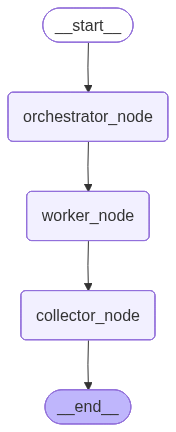

In [11]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(complex_graph.get_graph().draw_mermaid_png())

In [12]:
complex_graph.invoke(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    }
)

{'tasks': ['What is the capital of France and what is the population of Paris?',
  'What is the capital of Germany and what is the population of Berlin?'],
 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?',
 'results': ["The capital of France is **Paris**.\n\nThe population of Paris (city proper) is approximately **2.1 million to 2.2 million** as of recent estimates (e.g., 2023/2024).\n\nIt's worth noting that the population of the larger Paris metropolitan area is significantly higher, around 12-13 million.",
  'The capital of Germany is **Berlin**.\n\nAs of late 2023 / early 2024, the population of Berlin is approximately **3.7 to 3.8 million residents**.'],
 'summary': 'The worker results provide the capital cities and their approximate populations:\n\n*   **Paris, France:** Population of approximately **2.1-2.2 million** (city proper) as of 2023/2024.\n*   **Berlin, Germany:** Popula

In [13]:
for chunk in complex_graph.stream(
    {
        "query": "What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?",
        "tasks": [],
        "results": [],
        "summary": "",
    },
    stream_mode="updates"
):
    print(chunk)

{'orchestrator_node': {'tasks': ['What is the capital of France and what is the population of Paris?', 'What is the capital of Germany and what is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['What is the capital of France and what is the population of Paris?', 'What is the capital of Germany and what is the population of Berlin?'], 'query': 'What is the capital of France and what is the population of Paris? & What is the capital of Germany and what is the population of Berlin?', 'results': ["The capital of France is **Paris**.\n\nThe population of Paris (city proper) is approximately **2.1 million to 2.2 million** as of recent estimates (e.g., 2023/2024).\n\nIt's worth noting that the population of the larger Paris metropolitan area is significantly higher, around 12-13 million.", 'The capital of